# **Evaluatie Exreme neerslag**

# 0. Probleemstelling extreme neerslag

Noot: repliceerbaarheid en versioning:

Indien deze nota in pdf of Word beschikbaar is, kan men steeds de nieuwste versie en de repliceerbare code op GitHub vinden:
https://github.com/ReinhardStoop/neerslag_vs

## 0.1. Context

Op de website van Statistiek Vlaanderen wordt een VOS gepubliceert over neerslagextremen.
Zie https://www.vlaanderen.be/statistiek-vlaanderen/milieu-en-natuur/neerslagextremen

Deze cijfers en trendanalyse worden aangeleverd door VMM, die deze ook zelf online publiceert.
Zie https://vmm.vlaanderen.be/feiten-cijfers/klimaat/klimaatthemas/wateroverlast-door-hevige-regenval/indicator-neerslagextremen

Ook het KMI publiceert deze gegevens en analyse:
https://www.meteo.be/nl/klimaat/klimaatverandering-in-belgie/klimaattrends-in-ukkel/neerslag/extremiteitsindices/max-10-dagen-neerslag

Op de website van het KMI vindt men ook klimaatrapporten waarin de methodologie voor trendanalyses op klimaattijdreeksen wordt uitgelegd.
Zie https://www.meteo.be/nl/klimaat/klimaatverandering-in-belgie/klimaatrapporten

Het klimaatrapport van 2020 geeft helder weer welke methodologische overwegingen belangrijk zijn bij het analyseren van klimaattijdreeksen. 

We gebruiken in deze kwaliteitsevaluatie ook expliciet het volgende referentiewerk van KNMI, dat aansluit bij de KMI-klimaatrapportering:
KNMI: **Standard method for determining a climatological trend**, C.F. de Valk, De Bilt, 2020, Technical report TR-389.
https://cdn.knmi.nl/system/ckeditor_assets/attachments/161/TR389.pdf

## 0.2. Vaststelling

Heel algemeen wijken de trendberekeningen en voorstellingen van VMM soms af van die van het KMI.

In het bijzonder bekijken we in deze nota de reeks van neerslagextremen over 10 dagen. Door VMM (en overgenomen door VSA) wordt op de volledige tijdreeks een regressieanalyse toegepast, met als conclusie dat er een *positieve significante* trend is. Op de website van het KMI echter wordt deze reeks visueel voorgesteld op basis van LOESS (zie verder) en wordt een recente trendberekening (30 jaar) apart beoordeeld, deze is dan *niet significant*.


## 0.3. Doelstelling

We doen een replicatie en evaluatie van deze berekeningen. De analyse wordt uitgevoerd in Python op een reproduceerbare manier, zodat ze via een notebook future-proof kan worden opgenomen in de VSA Databricks-omgeving.

## 0.4. Aanpak

- We werken de data-analyse uit volgens de methodiek van het KMI: met de meest recente data doen we een replicatieonderzoek volgens de KMI/KNMI-benadering.
- We repliceren de regressieanalyse van VMM. Daarbij bespreken we de statistische beperkingen en toetsen we onder meer autocorrelatie omdat die relevant zijn voor de onzekerheid rond een enkelvoudige OLS-regressie.
- Ten slotte plaatsen we de resultaten naast elkaar. Dat is een kwaliteits- en methodenvergelijking, geen zelfstandig klimaatwetenschappelijk onderzoek. Waarbij we wel de richtlijnen voor tijdreeksanalyses en trend analyses in het kader van klimaatonderozek en communicatie hierover willen volgen.


# 1. Analyse vragen en data setup: "Extreme neerslag in Belgie: jaarlijkse maxima over 10 dagen"

## 1.1. Onderzoeksvragen

Deze notebook analyseert de jaarlijkse maximale neerslag over een periode van 10 opeenvolgende dagen. De focus ligt op drie vragen:

1. Hoe evolueert de volledige meetreeks doorheen de tijd? Is het methodologisch verdedigbaar om, zoals VMM doet, één globale OLS-regressie over de volledige meetperiode te gebruiken als hoofdboodschap voor de trend?. zie https://vmm.vlaanderen.be/feiten-cijfers/klimaat/klimaatthemas/wateroverlast-door-hevige-regenval/
2. Wat indien we de methodiek toepassen zoals deze in het klimaatrapport van het KMI is uitgewerkt en door het KMI gebruikt wordt. 
   Bijkomend: Is er sinds 1981 een recente lineaire trend, zoals in de KMI-klimaatrapportage vaak wordt gebruikt?
3. Is de conclusie over de trend gevoelig voor de keuze van de analyseperiode, bijvoorbeeld wanneer men enkel de periode vanaf 1981 of het laatste beschikbare 30-jarige venster bekijkt??

De analyse gebruikt de KMI/KNMI-Methodiek als leidraad: een gladde LOESS-curve voor de volledige reeks en een aparte recente trend vanaf 1981. Omdat extreme neerslag veel natuurlijke variabiliteit bevat, rapporteren we naast de schattingen ook robuuste onzekerheid en gevoeligheidschecks.


## 1.2. Setup en data

De ruwe Excel wordt (toegeleverd door VMM) omgezet naar een compacte CSV. Daarna werkt de rest van de notebook uitsluitend met `processed_max_neerslag.csv`, zodat de analyse reproduceerbaar en sneller uitvoerbaar blijft.
[noot: Nog aan te vullen: exacte bronvermelding van het aangeleverde Excel-bestand, datum van ontvangst, versie, contactpersoon en eventuele metadata over homogenisatie of berekeningswijze.]

***API-notitie***

De jaarlijkse puntdata voor extreme neerslag zoals opgenomen in de VOS en getoond op de websites van VMM en KMI zitten niet als kant-en-klare afgeleide klimaatindicator in de KMI Open Data API. De KMI Open Data API bevat wel ruwe neerslagwaarnemingen waarmee dergelijke indicatoren berekend kunnen worden. Als de exacte berekeningsregels en homogenisatiekeuzes beschikbaar zijn, kan de data-ingress in principe verder geautomatiseerd worden rechtstreeks uit de opendata API van het KMI.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings('ignore')

PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
DATA_DIR = next((p / 'data' for p in PROJECT_ROOT_CANDIDATES if (p / 'data').exists()), Path('../data'))
CSV_PATH = DATA_DIR / 'processed_max_neerslag.csv'
EXCEL_CANDIDATES = [
    Path('../../Maximale neerslag.xlsx'),
    Path('../Maximale neerslag.xlsx'),
    Path('Maximale neerslag.xlsx'),
]

OBS_COL = 'Waarneming 10 dagen'
TREND_COL = 'Trendlijn 10 dagen'
START_RECENT = 1981
KNMI_LOESS_WINDOW = 42


plt.rcParams.update({
    'figure.figsize': (11, 6),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
})

COLORS = {
    'observed': '#4B5563',
    'loess': '#2563EB',
    'recent': '#DC2626',
    'accent': '#059669',
    'neutral': '#9CA3AF',
}


def create_processed_csv_from_excel(output_path=CSV_PATH):
    excel_path = next((path for path in EXCEL_CANDIDATES if path.exists()), None)
    if excel_path is None:
        raise FileNotFoundError(
            'Geen processed CSV en geen Excel-bestand gevonden. '
            'Plaats Maximale neerslag.xlsx in de projectmap of voer de datavoorbereiding uit.'
        )

    raw = pd.read_excel(excel_path, sheet_name='Data', engine='openpyxl')
    years = raw.iloc[2, 1:].values
    processed = pd.DataFrame({
        'Waarneming 1 uur': raw.iloc[9, 1:].values,
        'Waarneming 1 dag': raw.iloc[10, 1:].values,
        'Waarneming 10 dagen': raw.iloc[11, 1:].values,
        'Trendlijn 1 uur': raw.iloc[12, 1:].values,
        'Trendlijn 1 dag': raw.iloc[13, 1:].values,
        'Trendlijn 10 dagen': raw.iloc[14, 1:].values,
    }, index=years)
    processed.index.name = 'Jaar'
    output_path.parent.mkdir(parents=True, exist_ok=True)
    processed.to_csv(output_path)
    return output_path


def load_extreme_series(csv_path=CSV_PATH):
    if not csv_path.exists():
        create_processed_csv_from_excel(csv_path)

    df = pd.read_csv(csv_path)
    extreme = (
        df[['Jaar', OBS_COL]]
        .dropna()
        .rename(columns={OBS_COL: 'max10d_mm'})
        .assign(Jaar=lambda x: x['Jaar'].astype(int))
        .sort_values('Jaar')
        .reset_index(drop=True)
    )
    return df, extreme


def hac_lags(n):
    return max(1, int(np.floor(4 * (n / 100) ** (2 / 9))))


def format_p(value):
    if pd.isna(value):
        return ''
    return '<0,001' if value < 0.001 else f'{value:.3f}'.replace('.', ',')


df, extreme = load_extreme_series()



## 2. Beschrijving van de reeks

We selecteren voor de verdere analyse enkel de 10 dagen reeks. Elk datapunt is het hoogste 10-daagse neerslagtotaal binnen een jaar. Het gaat dus om jaarlijkse maxima, niet om jaargemiddelden. Daardoor is de interjaarlijkse variabiliteit groot en moeten zowel trends als significantietoetsen voorzichtig worden geïnterpreteerd.


,Kenmerk,Waarde
0,Aantal jaren,127
1,Periode,1898-2024
2,Gemiddelde,86.1 mm
3,Mediaan,84.6 mm
4,Standaardafwijking,19.8 mm
5,Maximum,158.8 mm
6,Jaar van maximum,1996


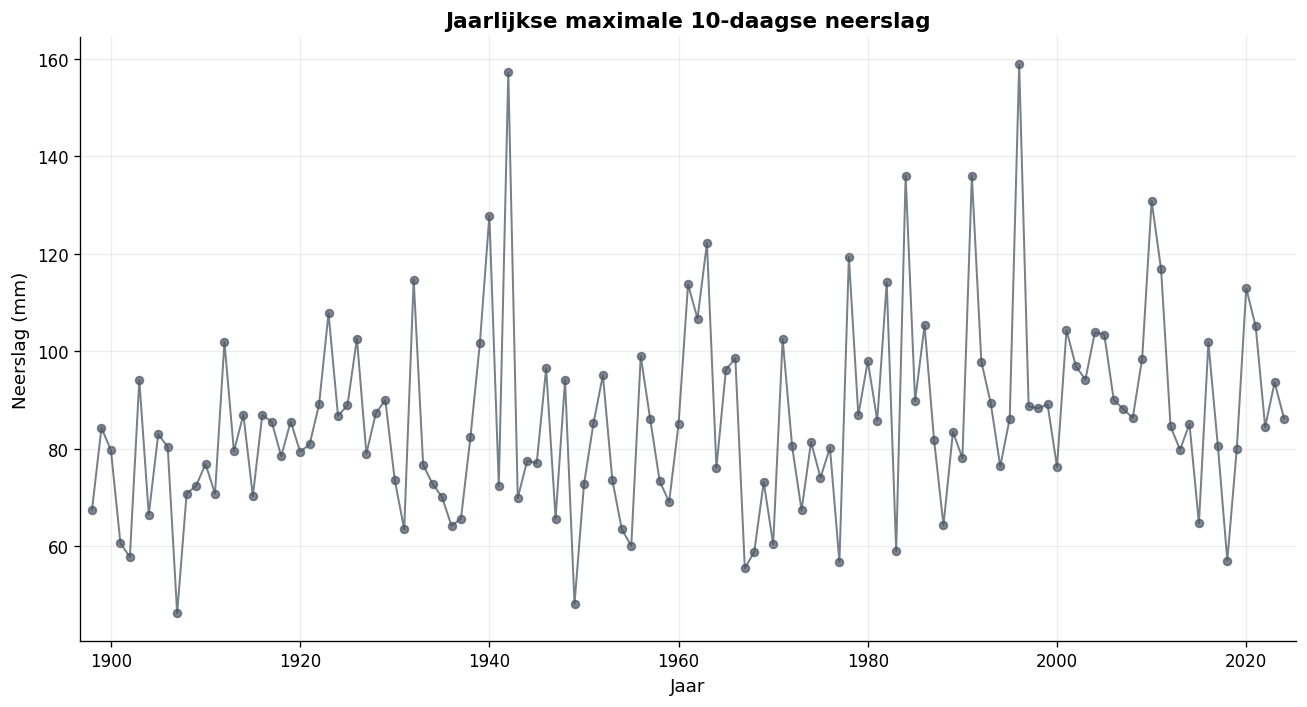

In [2]:
years = extreme['Jaar'].to_numpy(dtype=float)
values = extreme['max10d_mm'].to_numpy(dtype=float)

summary = pd.DataFrame({
    'Kenmerk': [
        'Aantal jaren',
        'Periode',
        'Gemiddelde',
        'Mediaan',
        'Standaardafwijking',
        'Maximum',
        'Jaar van maximum',
    ],
    'Waarde': [
        len(extreme),
        f'{int(years.min())}-{int(years.max())}',
        f'{values.mean():.1f} mm',
        f'{np.median(values):.1f} mm',
        f'{values.std(ddof=1):.1f} mm',
        f'{values.max():.1f} mm',
        int(years[values.argmax()]),
    ],
})

display(summary)

fig, ax = plt.subplots()
ax.plot(extreme['Jaar'], extreme['max10d_mm'], color=COLORS['observed'], linewidth=1.2, alpha=0.75)
ax.scatter(extreme['Jaar'], extreme['max10d_mm'], color=COLORS['observed'], s=22, alpha=0.70)
ax.set_title('Jaarlijkse maximale 10-daagse neerslag')
ax.set_xlabel('Jaar')
ax.set_ylabel('Neerslag (mm)')
ax.margins(x=0.01)
plt.tight_layout()
plt.show()


# 3. KMI / KNMI-methode

## 3.1. Methodologische samenvatting klimaatrapport KMI

In het KMI-klimaatrapport kan men de methodologie als volgt samenvatten wanneer we die plaatsen in de context van deze probleemstelling.

In dit KMI-klimaatrapport wordt voor waargenomen tijdreeksen een duidelijke tweesporenmethode gebruikt.

**1. Lange, gehomogeniseerde tijdreeksen**

Vooraleer trends worden berekend, benadrukt het KMI dat men klimaatverandering alleen zinvol kan analyseren met kwaliteitsvolle, voldoende lange en zo homogeen mogelijke tijdreeksen. Daarbij wordt gecorrigeerd voor niet-klimatologische breuken, zoals wijzigingen in meetstation, instrumenten, meetomgeving of waarnemingsprocedures. Zonder die stap kan een kunstmatige trend ontstaan die door meetomstandigheden komt en niet door klimaatverandering.

**2. Voor de grafieken systematisch twee technieken**

Het meest expliciet staat dit in het kader over de bepaling van klimatologische trends in de waarnemingen. Daarin worden twee technieken gecombineerd.

A. LOESS / lokale regressie als gladde trendcurve

Voor de volledige lange periode gebruikt men een gladde curve op de jaarlijkse waarden. Die vermindert de impact van interjaarlijkse variabiliteit en geeft een kwalitatief beeld van de meestal niet-lineaire evolutie over de hele periode. TR-389 beschrijft deze trendcurve technisch als lokale lineaire LOESS met tricubic gewichten over een venster van 42 jaar. De curve benadert inhoudelijk een 30-jaars lopend gemiddelde, maar met een lokale regressie in plaats van een eenvoudige gemiddeldewaarde.

B. Recente lineaire trends als aanvullende kwantificering

Het KMI-klimaatrapport gebruikt vaak een vaste recente referentieperiode vanaf 1981 om recente veranderingen te kwantificeren. Daarnaast kan een analyse van het laatste beschikbare 30-jarige venster nuttig zijn als gevoeligheidsanalyse, omdat 30 jaar aansluit bij de klassieke klimatologische referentieperiode. Dit laatste is echter niet hetzelfde als de TR-389-LOESS zelf.

**3. Wat bedoelt men met significant?**

In dit rapport is significantie niet overal exact hetzelfde criterium. Voor de Ukkel-grafieken wordt vaak een 90%-criterium gebruikt; voor ruimtelijke kaarten wordt eerder een 95%-significantieniveau gehanteerd. Daarom rapporteren we hier expliciet p-waarden en betrouwbaarheidsintervallen in plaats van alleen het label significant/niet significant.

Voor toetsing van verandering stelt het rapport niet voor om automatisch één globale regressie over de hele reeks te gebruiken.

**4. Welke methode is dus aanbevolen om klimaatverandering te beschrijven?**

Kort gezegd: voor detectie en beschrijving van klimaatverandering over lange tijd gebruikt men gehomogeniseerde lange tijdreeksen met LOESS/lokale regressie om de niet-lineaire evolutie zichtbaar te maken. Voor kwantificering van recente klimaatverandering gebruikt men een lineaire regressie vanaf een recente referentieperiode, met rapportering van helling, onzekerheid en significantie.

**5. Belangrijke nuance: OLS over de volledige eeuw is hoogstens een referentieanalyse**

Het KMI gebruikt geen eenvoudige globale lineaire regressie over de volledige beschikbare periode als hoofdboodschap voor klimaatverandering. In de TR-389-methodenvergelijking wordt een globale lineaire trend als minst geschikte algemene trendmethode gerangschikt voor lange klimaatreeksen, precies omdat ze één constante helling over de volledige periode veronderstelt.

Dat betekent niet dat een globale OLS-regressie rekenkundig fout is. Ze kan nuttig zijn als replicatie van de VMM-aanpak of als eenvoudige samenvattende referentie. Ze is alleen methodologisch te grof als hoofdboodschap voor een lange klimaatreeks.

**6. Inhoudelijke resultaten uit het rapport: voor temperatuur duidelijker dan voor neerslag**

Voor temperatuur concludeert het KMI ondubbelzinnig dat de seizoens- en jaartemperaturen sinds de 19e eeuw gestegen zijn, met een sterkere tweede opwarming vanaf het einde van de jaren 1980. Voor neerslag zijn de resultaten minder eenduidig, deels door de grotere natuurlijke variabiliteit. Daarom moet men voor neerslagextremen voorzichtiger zijn met sterke conclusies op basis van één model.

**7. Samenvatting**

De KMI/KNMI-benadering combineert homogenisatie, niet-lineaire trendvisualisatie met lokale lineaire LOESS en kwantificering van recente trends met lineaire regressie. LOESS beschrijft de vorm van de evolutie over de volledige periode zonder een constante trend te veronderstellen. De lineaire regressie vanaf 1981 rapporteert de recente verandering in interpreteerbare eenheden per decennium. Een globale OLS-trend over de volledige lange tijdreeks blijft nuttig als vergelijking met VMM, maar niet als enige klimaatboodschap.

## 3.2 Methodologisch referentiekader: KNMI TR-389 over klimatologische trendbepaling

et KNMI Technical Report TR-389, Standard method for determining a climatological trend, beschrijft een standaardmethode om klimatologische trends in tijdreeksen te bepalen voor reguliere KNMI-publicaties. Het rapport vertrekt van een belangrijke conceptuele definitie: een klimatologische trend is geen willekeurige regressielijn door alle waarnemingen, maar een representatie van de langetermijnverandering, waarbij kortetermijnfluctuaties door jaarlijkse weersvariabiliteit worden uitgefilterd. Een trend wordt in die benadering afgeleid uit een gladde trendlijn of smooth van de tijdreeks.

Het rapport vergelijkt verschillende mogelijke methoden om zo’n trendlijn te bepalen: het klassieke 30-jaars lopend gemiddelde, een globale lineaire regressie, GAM-smoothing en lokale polynomiale regressie of LOESS. Die methoden worden niet enkel beoordeeld op statistische elegantie, maar op een reeks praktische en klimatologisch relevante criteria: eenvoud, toepasbaarheid op verschillende klimaatvariabelen, lokaliteit in de tijd, flexibiliteit, aansluiting bij de klimatologische conventie van 30-jaarsgemiddelden, beperking van arbitraire keuzes en beschikbaarheid over de volledige periode.

In die vergelijking krijgt het klassieke 30-jaars lopend gemiddelde een sterke inhoudelijke positie, omdat het aansluit bij de klimatologische conventie. Het gemiddelde over een glijdend venster van 30 jaar dempt de jaarlijkse variabiliteit en geeft een herkenbare maat voor langetermijnverandering. Het nadeel is echter dat het niet goed gedefinieerd is aan het begin en vooral aan het einde van de tijdreeks: voor de recentste jaren ontbreken immers toekomstige waarnemingen om een gecentreerd 30-jaarsgemiddelde te berekenen. Daardoor is het klassieke 30-jaarsgemiddelde minder geschikt als operationele methode om de volledige reeks, inclusief de meest recente jaren, weer te geven.

Lineaire regressie wordt in TR-389 wel besproken als een eenvoudige methode, maar ze wordt methodologisch zwak beoordeeld als algemene methode voor klimatologische trendbepaling. De reden is niet dat lineaire regressie rekenkundig fout zou zijn. De reden is dat één globale rechte lijn over een lange tijdreeks een sterke vormaanname oplegt: de verandering wordt verondersteld constant lineair te verlopen over de volledige periode. Daardoor is de methode niet lokaal in de tijd, niet flexibel, en sluit ze niet goed aan bij de klimatologische conventie van 30-jaarsgemiddelden. Bovendien hangt de conclusie van zo’n globale regressie sterk af van het gekozen begin- en eindjaar. Een significante helling over de volledige reeks betekent dan vooral dat de gemiddelde lineaire helling over die hele historische periode van nul verschilt; ze zegt niet noodzakelijk dat er ook in de recente periode een duidelijke of significante stijging aanwezig is.

Als standaardmethode kiest TR-389 daarom voor een specifieke vorm van lokale lineaire regressie: een LOESS-trendlijn met tricubische gewichten over een venster van 42 jaar. Die keuze is niet arbitrair bedoeld, maar is afgestemd op de klimatologische 30-jaarsconventie. Door de tricubische weging is een breder venster nodig om ongeveer dezelfde variantie te bekomen als een ongewogen 30-jaarsgemiddelde. De methode wordt in het rapport samengevat als een “gladde trendlijn, bij benadering het 30-jaars lopend gemiddelde”. Technisch gaat het om lokale lineaire kleinste-kwadratenregressie met een tricubische weegfunctie over een 42-jaarsvenster.

Het belangrijke voordeel van deze LOESS-benadering is dat ze tegelijk lokaal, flexibel en klimatologisch interpreteerbaar is. Lokaal betekent dat de trendwaarde in een bepaald jaar alleen gebaseerd is op waarnemingen in een beperkte tijdsomgeving. Daardoor wordt vermeden dat zeer oude waarnemingen de interpretatie van recente evoluties blijven domineren. Flexibel betekent dat de trendlijn niet gedwongen wordt om één rechte lijn te zijn: versnellingen, vertragingen, plateaus of niet-lineaire evoluties kunnen zichtbaar worden. Klimatologisch interpreteerbaar betekent dat de methode dicht aansluit bij het vertrouwde 30-jaarsgemiddelde, maar zonder de praktische problemen aan het begin en einde van de reeks.

TR-389 maakt daarbij ook een belangrijk onderscheid tussen het weergeven van de volledige langetermijnevolutie en het toetsen van verandering. Voor de volledige reeks beveelt het rapport de LOESS-trendlijn aan. * Voor toetsing van verandering stelt het rapport niet voor om automatisch één globale regressie over de hele reeks te gebruiken.* De aanbevolen toetsing vertrekt van verschillen tussen twee vooraf gekozen, voldoende gescheiden jaren op de geschatte trendlijn. De gedachte daarachter is dat klimaatverandering niet noodzakelijk als één constante lineaire helling over de volledige meetperiode hoeft te verlopen. Een toets moet daarom aansluiten bij de trendlijn en bij een expliciete keuze van de periode waarover men verandering wil beoordelen.

In de context van deze evaluatie is dat onderscheid cruciaal. De VMM/VSA-benadering waarbij een lineaire regressie over de volledige neerslagreeks wordt toegepast, levert een statistisch berekenbare globale helling op. Die analyse beantwoordt echter een andere vraag dan de vraag die in klimaatrapportering centraal staat. Ze test of er gemiddeld over de volledige periode een lineaire stijging is, maar ze beschrijft niet noodzakelijk correct de vorm van de langetermijnevolutie en zegt weinig over de recentste klimaatevolutie. Voor een reeks zoals de maximale 10-daagse neerslag, die sterk varieert van jaar tot jaar en mogelijk niet-lineair evolueert, is die globale OLS-trend daarom beter te beschouwen als een aanvullende samenvatting, niet als hoofdindicator voor de klimatologische trend.

Een regressie op de laatste 30 jaar heeft een andere functie. Ze is geen vervanging van de TR-389-trendlijn, maar kan wel als aanvullende gevoeligheidsanalyse gebruikt worden. Omdat 30 jaar overeenkomt met de klassieke klimatologische referentieperiode, is een lineaire regressie over de recentste 30 jaar inhoudelijk beter verdedigbaar dan een regressie over de volledige historische reeks wanneer men specifiek de recente evolutie wil samenvatten. De interpretatie blijft echter beperkt: de geschatte helling zegt alleen iets over de gemiddelde lineaire verandering binnen dat recente venster. Bij neerslagextremen is de jaarlijkse variabiliteit groot, waardoor de onzekerheid rond zo’n helling vaak breed is. Een niet-significante trend over de laatste 30 jaar betekent dus niet dat er zeker geen verandering is, maar wel dat de beschikbare jaarwaarden binnen dat venster onvoldoende statistisch bewijs geven voor een duidelijke monotone lineaire stijging.

Voor deze nota betekent dit dat drie resultaten duidelijk uit elkaar moeten worden gehouden. Ten eerste is er de globale OLS-regressie over de volledige reeks: die kan significant positief zijn, maar is sterk modelafhankelijk en klimatologisch minder geschikt als hoofdconclusie. Ten tweede is er de LOESS-trendlijn volgens de TR-389-logica: die geeft de meest passende beschrijvende voorstelling van de langetermijnevolutie, omdat ze de 30-jaarsklimatologische conventie benadert en niet-lineaire evoluties toelaat. Ten derde is er de regressie over de recente periode, bijvoorbeeld vanaf 1981 of over de laatste 30 jaar: die is nuttig om de recente lineaire evolutie afzonderlijk te toetsen, maar moet met ruime onzekerheidsmarges en voorzichtige taal worden geïnterpreteerd.

## 3.3. Methodologische kernconclusie
De methodologische kernconclusie is dus niet dat lineaire regressie als techniek 'fout' is. De kern is dat één globale lineaire regressie over een lange klimaatreeks een te sterke en te weinig klimatologische modelkeuze is om als centrale trendboodschap te gebruiken. Een wetenschappelijk robuustere aanpak combineert een gladde lokale trendlijn voor de volledige reeks met een aparte, expliciet afgebakende analyse van recente verandering. Dat sluit beter aan bij de methodologische redenering van KNMI TR-389 en bij de manier waarop klimaatindicatoren voorzichtig moeten worden gecommuniceerd.

> ***Tegen deze methodologische achtergrond wordt hieronder nagegaan hoe de conclusie op basis van een globale OLS-regressie zich verhoudt tot een LOESS-gebaseerde beschrijving van de volledige reeks en tot een afzonderlijke trendanalyse voor de recente periode. Waarbij we 1981 als referentie gebruiken conform het KMI klimaatrapport en een venster van de laatste 30 jaar conform de het Technisch Rapport TR-389 over klimatologische trendbepaling van het KNMI. 
> We doen voor alle deze methoden een review en replicatie.***



## 3.2 KNMI/TR-389 LOESS: lokale lineaire trend met 42-jaarsvenster

Voor de volledige periode gebruiken we hier de KNMI/TR-389-benadering: lokale lineaire LOESS met een venster van 42 jaar en tricubic gewichten. In `statsmodels.lowess` betekent dit dat de fractie gelijk is aan `42 / n`. We zetten `it=0`, zodat er geen extra robuuste iteraties worden toegepast bovenop de lokale lineaire regressie.

Daarnaast tonen we een gecentreerd 30-jaars lopend gemiddelde. Dat is geen vervanging van de TR-389-LOESS, maar een inhoudelijke referentie omdat de LOESS-trendlijn volgens TR-389 ongeveer een 30-jaars lopend gemiddelde benadert.


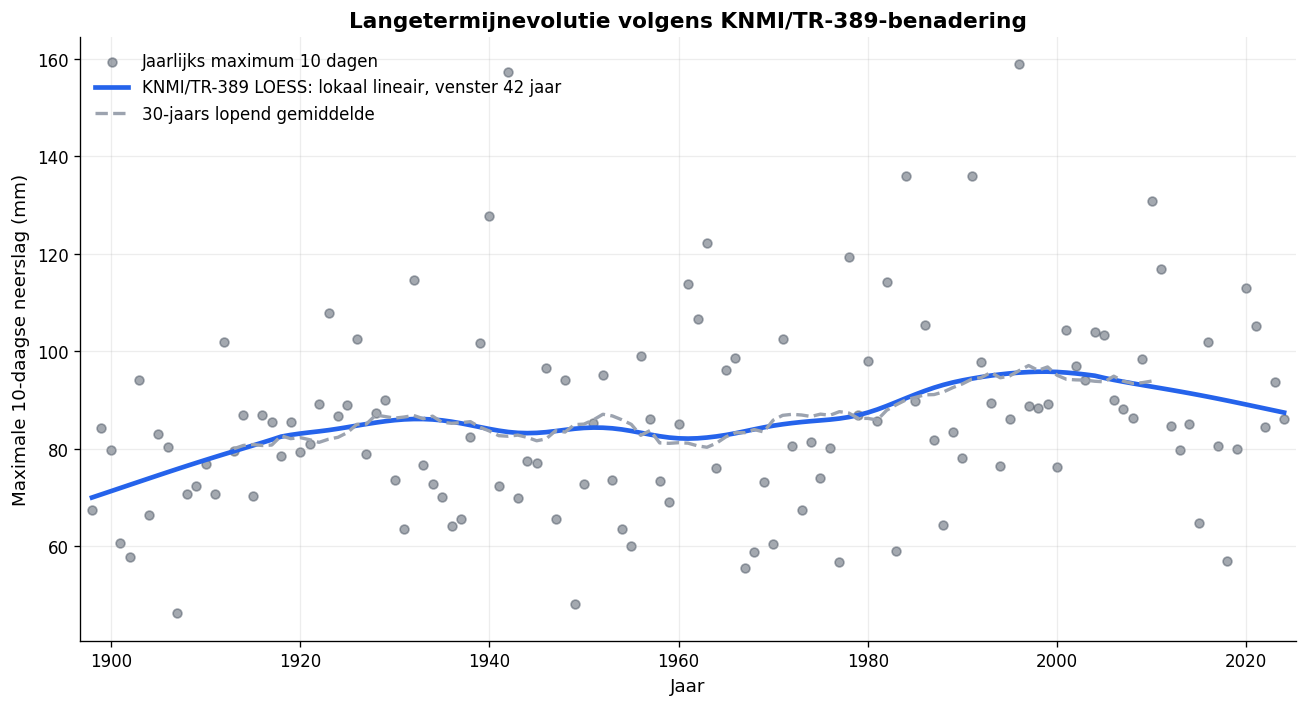

,Jaar,source_trend,knmi_loess_python,verschil_source_vs_python
count,127.000,127.000,127.000,127.000
mean,1961.000,86.107,85.847,0.259
std,36.806,5.151,6.091,3.261
min,1898.000,77.290,70.019,-4.619
25%,1929.500,81.699,83.161,-2.860
50%,1961.000,86.107,85.083,0.350
75%,1992.500,90.515,90.509,2.626
max,2024.000,94.923,95.820,7.489


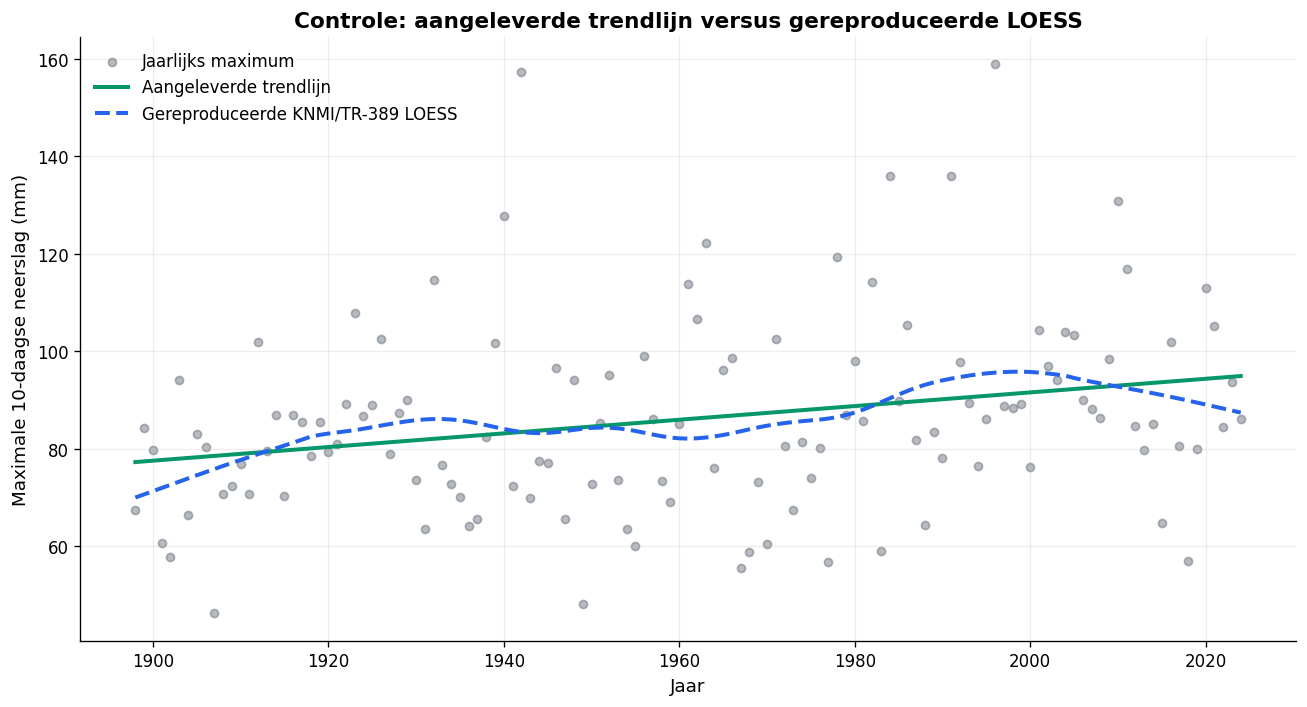

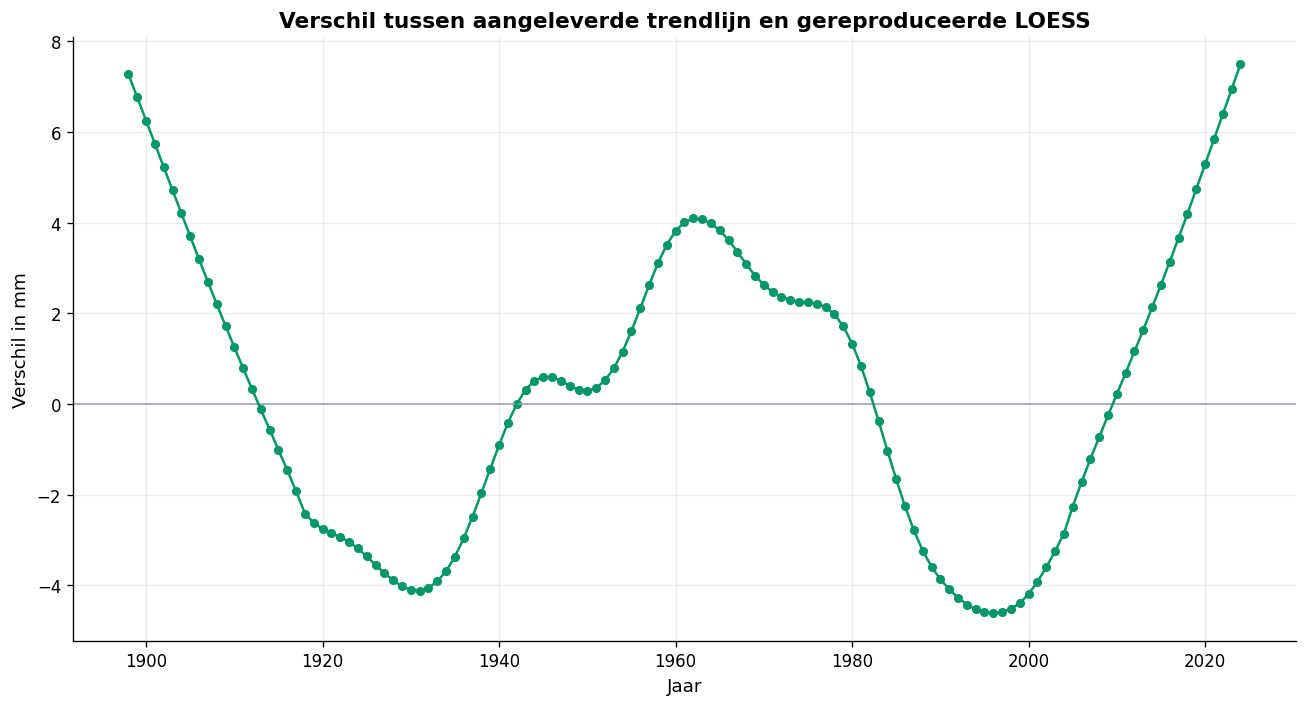

In [3]:
# 3.2 KNMI/TR-389 LOESS: lokale lineaire trend met 42-jaarsvenster
LOESS_FRAC_KNMI = KNMI_LOESS_WINDOW / len(extreme)

loess_knmi = lowess(
    values,
    years,
    frac=LOESS_FRAC_KNMI,
    it=0,
    return_sorted=True,
)

# Compatibiliteit met latere cellen die de volledige trendcurve plotten.
loess_curve = loess_knmi

rolling_30 = (
    extreme
    .set_index('Jaar')['max10d_mm']
    .rolling(window=30, center=True)
    .mean()
)

fig, ax = plt.subplots()

ax.scatter(
    years,
    values,
    color=COLORS['observed'],
    alpha=0.50,
    s=28,
    label='Jaarlijks maximum 10 dagen',
)

ax.plot(
    loess_knmi[:, 0],
    loess_knmi[:, 1],
    color=COLORS['loess'],
    linewidth=2.8,
    label=f'KNMI/TR-389 LOESS: lokaal lineair, venster {KNMI_LOESS_WINDOW} jaar',
)

ax.plot(
    rolling_30.index,
    rolling_30.values,
    color=COLORS['neutral'],
    linewidth=2.0,
    linestyle='--',
    label='30-jaars lopend gemiddelde',
)

ax.set_title('Langetermijnevolutie volgens KNMI/TR-389-benadering')
ax.set_xlabel('Jaar')
ax.set_ylabel('Maximale 10-daagse neerslag (mm)')
ax.legend(loc='upper left')
ax.margins(x=0.01)
plt.tight_layout()
plt.show()

# Vergelijking aangeleverde trendlijn versus gereproduceerde KNMI/TR-389 LOESS
trend_compare = (
    df[['Jaar', OBS_COL, TREND_COL]]
    .dropna(subset=['Jaar', OBS_COL])
    .rename(columns={
        OBS_COL: 'observed',
        TREND_COL: 'source_trend',
    })
    .assign(Jaar=lambda x: x['Jaar'].astype(int))
    .sort_values('Jaar')
)

loess_knmi_df = pd.DataFrame({
    'Jaar': loess_knmi[:, 0].astype(int),
    'knmi_loess_python': loess_knmi[:, 1],
})

trend_compare = trend_compare.merge(loess_knmi_df, on='Jaar', how='left')
trend_compare['verschil_source_vs_python'] = (
    trend_compare['source_trend'] - trend_compare['knmi_loess_python']
)

display(
    trend_compare[['Jaar', 'source_trend', 'knmi_loess_python', 'verschil_source_vs_python']]
    .describe()
    .round(3)
)

fig, ax = plt.subplots()

ax.scatter(
    trend_compare['Jaar'],
    trend_compare['observed'],
    color=COLORS['observed'],
    alpha=0.40,
    s=24,
    label='Jaarlijks maximum',
)

ax.plot(
    trend_compare['Jaar'],
    trend_compare['source_trend'],
    color=COLORS['accent'],
    linewidth=2.4,
    label='Aangeleverde trendlijn',
)

ax.plot(
    trend_compare['Jaar'],
    trend_compare['knmi_loess_python'],
    color=COLORS['loess'],
    linewidth=2.4,
    linestyle='--',
    label='Gereproduceerde KNMI/TR-389 LOESS',
)

ax.set_title('Controle: aangeleverde trendlijn versus gereproduceerde LOESS')
ax.set_xlabel('Jaar')
ax.set_ylabel('Maximale 10-daagse neerslag (mm)')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots()
ax.axhline(0, color=COLORS['neutral'], linewidth=1)
ax.plot(
    trend_compare['Jaar'],
    trend_compare['verschil_source_vs_python'],
    color=COLORS['accent'],
    linewidth=1.5,
)
ax.scatter(
    trend_compare['Jaar'],
    trend_compare['verschil_source_vs_python'],
    color=COLORS['accent'],
    s=20,
)
ax.set_title('Verschil tussen aangeleverde trendlijn en gereproduceerde LOESS')
ax.set_xlabel('Jaar')
ax.set_ylabel('Verschil in mm')
plt.tight_layout()
plt.show()


## 3.3. Recente trend vanaf 1981 en laatste 30 jaar

De recente verandering wordt apart geschat met een lineaire trend vanaf 1981. Dat is een vaste recente referentieperiode, geen exact 30-jaarsvenster. Daarom tonen we daarnaast ook het laatste beschikbare 30-jaarsvenster. De helling wordt uitgedrukt in mm per decennium. De onzekerheid gebruikt HAC/Newey-West standaardfouten, zodat de p-waarde minder gevoelig is voor autocorrelatie en heteroskedasticiteit in de residualen.


,Periode,n,Trend,90% BI,p-waarde,HAC maxlags
0,1981-2024,44,-1.47 mm/decennium,-4.57 tot 1.62,"0,428",3
1,1995-2024,30,-5.38 mm/decennium,-11.15 tot 0.39,"0,124",3


,Methode,Schatting,Onzekerheid / toets
0,Lineaire trend vanaf 1981 met HAC-onzekerheid,-1.47 mm/decennium,"90% BI -4.57 tot 1.62; p = 0,428"
1,Theil-Sen robuuste helling vanaf 1981,-0.65 mm/decennium,90% BI -3.80 tot 2.61 mm/decennium
2,Mann-Kendall monotone trend vanaf 1981,tau = -0.041,"p = 0,701"


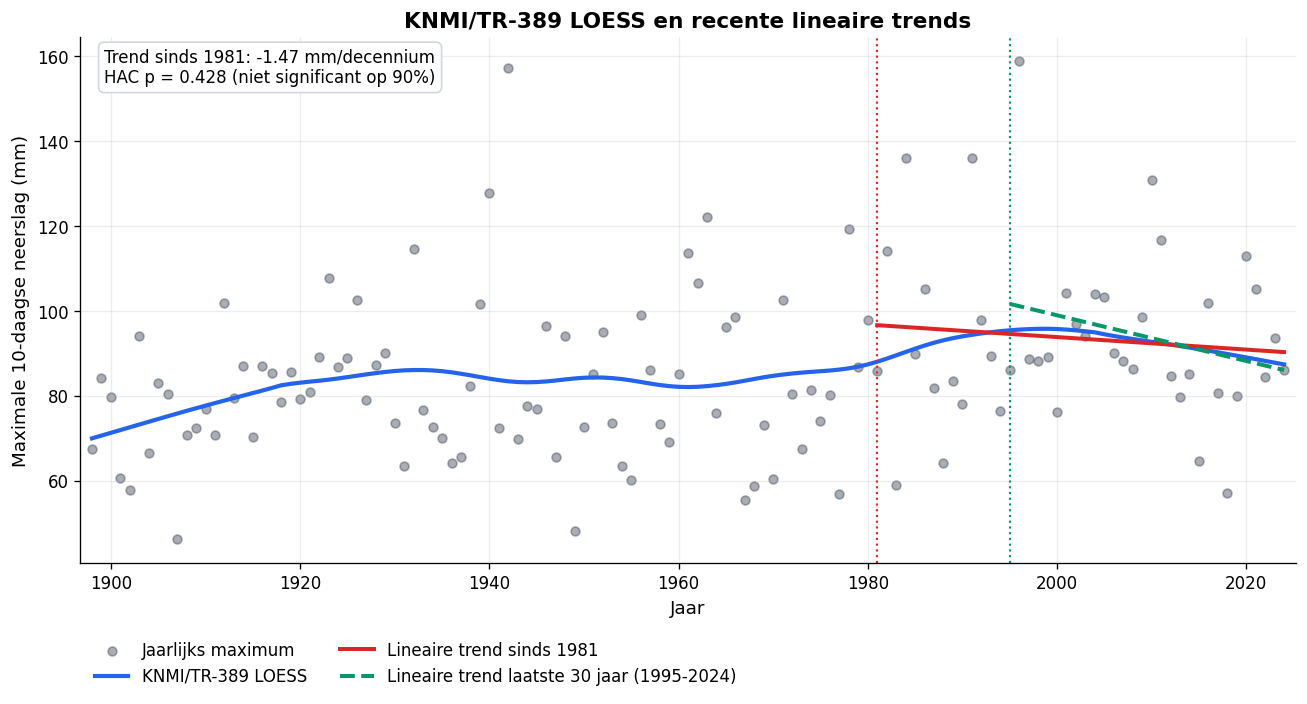

In [4]:
# Bij sectie 3.3.
def fit_linear_trend_period(data, start_year, y_col='max10d_mm', alpha=0.10):
    d = data.loc[data['Jaar'] >= start_year].copy()
    d = d.dropna(subset=['Jaar', y_col])

    t = d['Jaar'].to_numpy(dtype=float) - start_year
    y = d[y_col].to_numpy(dtype=float)

    X = sm.add_constant(t)
    ols = sm.OLS(y, X).fit()

    maxlags = hac_lags(len(d))
    hac = ols.get_robustcov_results(
        cov_type='HAC',
        maxlags=maxlags,
        use_t=True,
    )

    ci = np.asarray(hac.conf_int(alpha=alpha))[1] * 10

    return {
        'startjaar': start_year,
        'eindjaar': int(d['Jaar'].max()),
        'n': len(d),
        'helling_mm_per_decennium': hac.params[1] * 10,
        'ci_laag': ci[0],
        'ci_hoog': ci[1],
        'p_waarde': hac.pvalues[1],
        'hac_maxlags': maxlags,
        'r2_ols': ols.rsquared,
        'model': ols,
        'hac': hac,
        'data': d,
    }


def mann_kendall_test(series):
    series = np.asarray(series, dtype=float)
    n = len(series)
    s = 0.0
    for k in range(n - 1):
        s += np.sign(series[k + 1:] - series[k]).sum()

    _, counts = np.unique(series, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    var_s = (n * (n - 1) * (2 * n + 5) - tie_term) / 18
    z = (s - 1) / np.sqrt(var_s) if s > 0 else (s + 1) / np.sqrt(var_s) if s < 0 else 0.0
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    tau = s / (0.5 * n * (n - 1))
    return tau, p_value


last_year = int(extreme['Jaar'].max())
start_last_30 = last_year - 29

trend_1981 = fit_linear_trend_period(extreme, START_RECENT)
trend_30 = fit_linear_trend_period(extreme, start_last_30)

recent_comparison = pd.DataFrame([
    {
        'Periode': f"{trend_1981['startjaar']}-{trend_1981['eindjaar']}",
        'n': trend_1981['n'],
        'Trend': f"{trend_1981['helling_mm_per_decennium']:.2f} mm/decennium",
        '90% BI': f"{trend_1981['ci_laag']:.2f} tot {trend_1981['ci_hoog']:.2f}",
        'p-waarde': format_p(trend_1981['p_waarde']),
        'HAC maxlags': trend_1981['hac_maxlags'],
    },
    {
        'Periode': f"{trend_30['startjaar']}-{trend_30['eindjaar']}",
        'n': trend_30['n'],
        'Trend': f"{trend_30['helling_mm_per_decennium']:.2f} mm/decennium",
        '90% BI': f"{trend_30['ci_laag']:.2f} tot {trend_30['ci_hoog']:.2f}",
        'p-waarde': format_p(trend_30['p_waarde']),
        'HAC maxlags': trend_30['hac_maxlags'],
    },
])

display(recent_comparison)

recent = trend_1981['data'].copy()
t_recent = recent['Jaar'].to_numpy(dtype=float) - START_RECENT
y_recent = recent['max10d_mm'].to_numpy(dtype=float)
ols_recent = trend_1981['model']
hac_recent = trend_1981['hac']
recent_hac_lags = trend_1981['hac_maxlags']

slope_decade = trend_1981['helling_mm_per_decennium']
ci90 = np.array([trend_1981['ci_laag'], trend_1981['ci_hoog']])
ci95 = np.asarray(hac_recent.conf_int(alpha=0.05))[1] * 10
p_hac = trend_1981['p_waarde']

sen = stats.theilslopes(y_recent, recent['Jaar'].to_numpy(dtype=float), alpha=0.90)
mk_tau, mk_p = mann_kendall_test(y_recent)

trend_table = pd.DataFrame({
    'Methode': [
        'Lineaire trend vanaf 1981 met HAC-onzekerheid',
        'Theil-Sen robuuste helling vanaf 1981',
        'Mann-Kendall monotone trend vanaf 1981',
    ],
    'Schatting': [
        f'{slope_decade:.2f} mm/decennium',
        f'{sen.slope * 10:.2f} mm/decennium',
        f'tau = {mk_tau:.3f}',
    ],
    'Onzekerheid / toets': [
        f'90% BI {ci90[0]:.2f} tot {ci90[1]:.2f}; p = {format_p(p_hac)}',
        f'90% BI {sen.low_slope * 10:.2f} tot {sen.high_slope * 10:.2f} mm/decennium',
        f'p = {format_p(mk_p)}',
    ],
})

display(trend_table)

recent_fit = hac_recent.params[0] + hac_recent.params[1] * t_recent
t_30 = trend_30['data']['Jaar'].to_numpy(dtype=float) - trend_30['startjaar']
fit_30 = trend_30['hac'].params[0] + trend_30['hac'].params[1] * t_30
significance = 'significant op 95%' if p_hac < 0.05 else 'significant op 90%' if p_hac < 0.10 else 'niet significant op 90%'

fig, ax = plt.subplots()
ax.scatter(years, values, color=COLORS['observed'], alpha=0.48, s=28, label='Jaarlijks maximum')
ax.plot(loess_knmi[:, 0], loess_knmi[:, 1], color=COLORS['loess'], linewidth=2.5, label='KNMI/TR-389 LOESS')
ax.plot(recent['Jaar'], recent_fit, color=COLORS['recent'], linewidth=2.4, label=f'Lineaire trend sinds {START_RECENT}')
ax.plot(trend_30['data']['Jaar'], fit_30, color=COLORS['accent'], linewidth=2.4, linestyle='--', label=f'Lineaire trend laatste 30 jaar ({start_last_30}-{last_year})')
ax.axvline(START_RECENT, color=COLORS['recent'], linestyle=':', linewidth=1.3)
ax.axvline(start_last_30, color=COLORS['accent'], linestyle=':', linewidth=1.3)
ax.text(
    0.02,
    0.98,
    f'Trend sinds {START_RECENT}: {slope_decade:.2f} mm/decennium\nHAC p = {p_hac:.3f} ({significance})',
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox={'facecolor': 'white', 'edgecolor': '#D1D5DB', 'alpha': 0.94, 'boxstyle': 'round,pad=0.35'},
)
ax.set_title('KNMI/TR-389 LOESS en recente lineaire trends')
ax.set_xlabel('Jaar')
ax.set_ylabel('Maximale 10-daagse neerslag (mm)')
ax.legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=2)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()


## 3.4. Gevoeligheidsanalyse: startjaar van de lineaire trend

Deze gevoeligheidsanalyse toont hoe de geschatte lineaire trend verandert wanneer hetzelfde model telkens op een andere startperiode wordt toegepast. Een robuuste klimatologische conclusie mag niet uitsluitend afhangen van één toevallig gekozen startjaar.


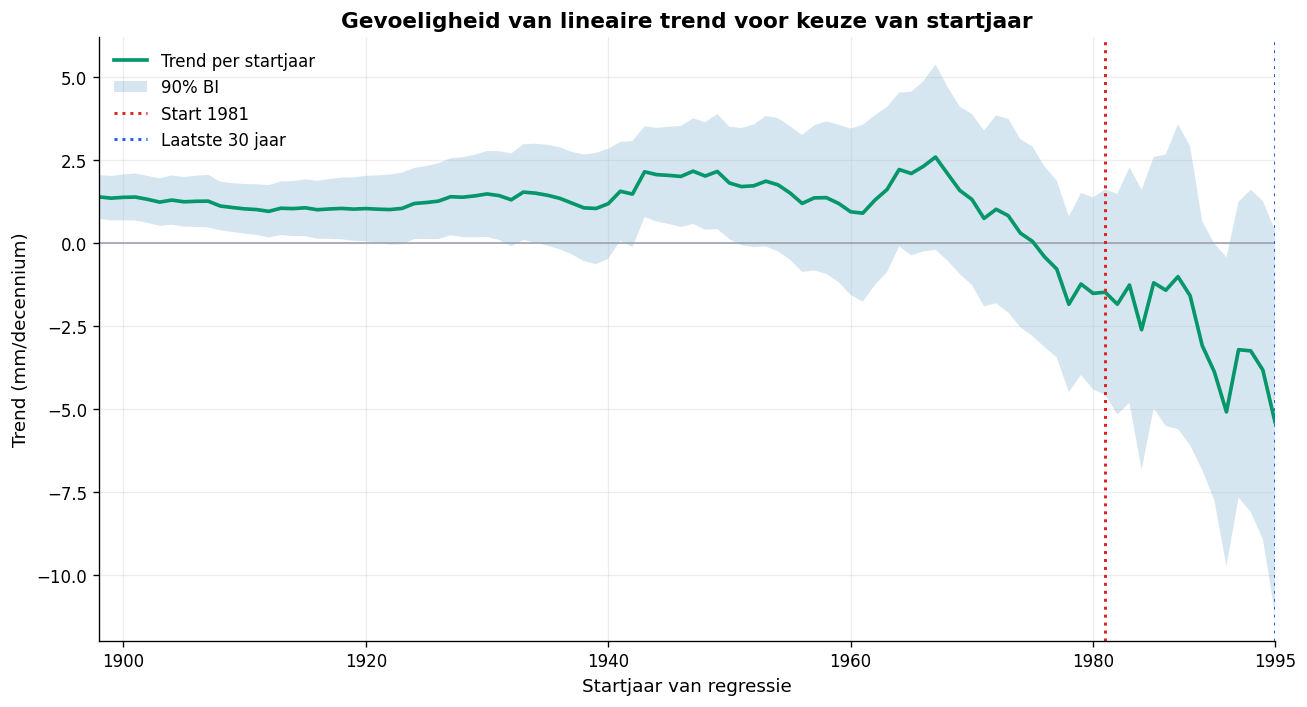

,startjaar,eindjaar,n,trend_mm_per_decennium,ci90_laag,ci90_hoog,p_waarde,significant_90,significant_95
0,1898,2024,127,1.399,0.738,2.059,0.001,True,True
53,1951,2024,74,1.711,-0.058,3.479,0.111,False,False
63,1961,2024,64,0.910,-1.759,3.578,0.571,False,False
73,1971,2024,54,0.752,-1.897,3.401,0.637,False,False
83,1981,2024,44,-1.475,-4.573,1.624,0.428,False,False
93,1991,2024,34,-5.083,-9.742,-0.423,0.074,True,False
97,1995,2024,30,-5.380,-11.153,0.393,0.124,False,False


In [5]:
# Gevoeligheidsanalyse: hoe verandert de trend bij ander startjaar?
min_period_length = 30
sensitivity_rows = []

for start in range(int(years.min()), int(years.max()) - min_period_length + 2):
    try:
        res = fit_linear_trend_period(extreme, start)
        sensitivity_rows.append({
            'startjaar': start,
            'eindjaar': res['eindjaar'],
            'n': res['n'],
            'trend_mm_per_decennium': res['helling_mm_per_decennium'],
            'ci90_laag': res['ci_laag'],
            'ci90_hoog': res['ci_hoog'],
            'p_waarde': res['p_waarde'],
            'significant_90': res['p_waarde'] < 0.10,
            'significant_95': res['p_waarde'] < 0.05,
        })
    except Exception:
        pass

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity_plot = sensitivity.loc[sensitivity['startjaar'] <= start_last_30].copy()

fig, ax = plt.subplots()

ax.axhline(0, color=COLORS['neutral'], linewidth=1)
ax.plot(
    sensitivity_plot['startjaar'],
    sensitivity_plot['trend_mm_per_decennium'],
    color=COLORS['accent'],
    linewidth=2.2,
    label='Trend per startjaar',
)

ax.fill_between(
    sensitivity_plot['startjaar'].to_numpy(),
    sensitivity_plot['ci90_laag'].to_numpy(),
    sensitivity_plot['ci90_hoog'].to_numpy(),
    alpha=0.18,
    label='90% BI',
)

ax.axvline(1981, color=COLORS['recent'], linestyle=':', linewidth=1.8, label='Start 1981')
ax.axvline(start_last_30, color=COLORS['loess'], linestyle=':', linewidth=1.8, label='Laatste 30 jaar')

ax.set_xlim(sensitivity_plot['startjaar'].min(), start_last_30)
xticks = sorted(set(int(tick) for tick in ax.get_xticks()) | {start_last_30})
ax.set_xticks([tick for tick in xticks if sensitivity_plot['startjaar'].min() <= tick <= start_last_30])

ax.set_title('Gevoeligheid van lineaire trend voor keuze van startjaar')
ax.set_xlabel('Startjaar van regressie')
ax.set_ylabel('Trend (mm/decennium)')
ax.legend()
plt.tight_layout()
plt.show()

display(
    sensitivity.loc[
        sensitivity['startjaar'].isin([int(years.min()), 1951, 1961, 1971, 1981, 1991, start_last_30])
    ].round(3)
)


**Interpretatie gevoeligheidsanalyse**

Deze gevoeligheidsanalyse toont dat de conclusie over een lineaire trend afhangt van de gekozen analyseperiode. De volledige reeks, en enkel deze, (1998-2024) geeft een positieve significante gemiddelde helling, maar de recente periode vanaf 1981 niet. Voor 1991-2024 vinden we zelf een negatief significant trend op .90 niveau. Dat bevestigt dat de globale OLS-trend vooral een modelmatige samenvatting over de volledige historische periode is, niet noodzakelijk een geschikte indicator voor de actuele klimaatevolutie.

Dit is ook de hoofdreden waarom LOESS benadering qua visualisatie van de trend eengewezen is en niet de voorstelling van een regressierechte voor de ganse poeriode. 



## 4. OLS regressie volledige reeks

### 4.1. Replicatie van VMM trend rechte
Als eenvoudige referentie schatten we voor de hele meetperiode een gewone OLS-regressie met een lineaire tijdtrend. Deze rechte lijn, alms zuivere replicatie van de VMM trend lijn, is vooral een samenvattende toets: ze laat zien of er gemiddeld over de volledige reeks een lineaire stijging of daling aanwezig is, terwijl de LOESS-curve daarnaast de niet-lineaire vorm van de evolutie blijft tonen.




,Parameter,Schatting,Std. fout,t-waarde,p-waarde,CI95 laag,CI95 hoog,Eenheid
0,Intercept,77.297,3.386,22.826,"<0,001",70.595,83.999,mm bij startjaar
1,Trend,1.399,0.465,3.011,"0,003",0.479,2.318,mm/decennium


,Kenmerk,Waarde
0,Aantal jaren,127
1,Periode,1898-2024
2,R-kwadraat,0.067606
3,Adjusted R-kwadraat,0.060146
4,F-statistic p-waarde,"0,003"
5,RMSE residualen (mm),19.04232


,Test,Waarde
0,Durbin-Watson residualen,2.002129
1,Lag-1 autocorrelatie residualen,-0.002953
2,Ljung-Box lag 10 p-waarde,"0,544"
3,Breusch-Pagan p-waarde,"0,390"
4,Shapiro-Wilk p-waarde,"<0,001"


,Ljung-Box statistic,p-waarde
1,0.0011,0.9733
5,2.0525,0.8418
10,8.8798,0.5435


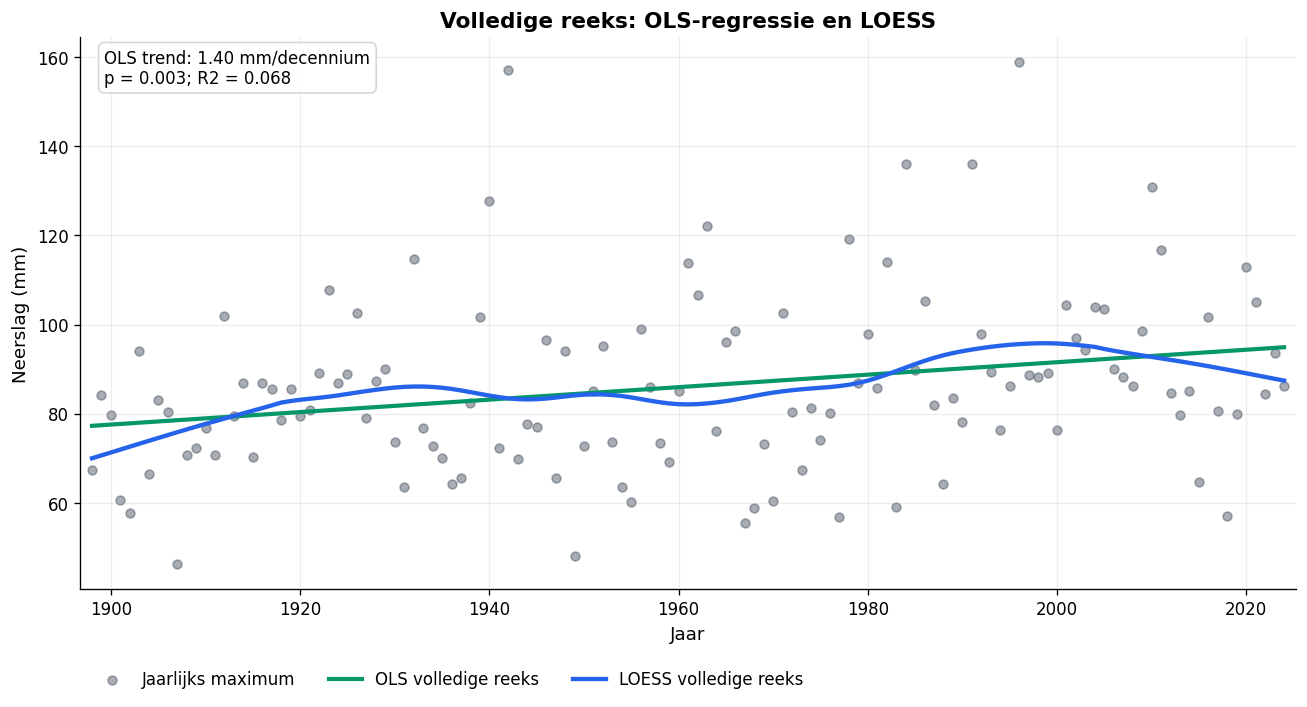

In [6]:
# Gewone OLS-regressie over de volledige reeks
t_full = years - years.min()
ols_full = sm.OLS(values, sm.add_constant(t_full)).fit()
full_fit = ols_full.predict(sm.add_constant(t_full))
full_residuals = pd.Series(ols_full.resid, index=extreme['Jaar'])

slope_full_year = ols_full.params[1]
slope_full_decade = slope_full_year * 10
ci95_full_decade = ols_full.conf_int(alpha=0.05)[1] * 10
p_full = ols_full.pvalues[1]

ols_table = pd.DataFrame({
    'Parameter': ['Intercept', 'Trend'],
    'Schatting': [ols_full.params[0], slope_full_decade],
    'Std. fout': [ols_full.bse[0], ols_full.bse[1] * 10],
    't-waarde': [ols_full.tvalues[0], ols_full.tvalues[1]],
    'p-waarde': [format_p(ols_full.pvalues[0]), format_p(p_full)],
    'CI95 laag': [ols_full.conf_int(alpha=0.05)[0, 0], ci95_full_decade[0]],
    'CI95 hoog': [ols_full.conf_int(alpha=0.05)[0, 1], ci95_full_decade[1]],
    'Eenheid': ['mm bij startjaar', 'mm/decennium'],
})

model_fit_table = pd.DataFrame({
    'Kenmerk': [
        'Aantal jaren',
        'Periode',
        'R-kwadraat',
        'Adjusted R-kwadraat',
        'F-statistic p-waarde',
        'RMSE residualen (mm)',
    ],
    'Waarde': [
        int(ols_full.nobs),
        f'{int(years.min())}-{int(years.max())}',
        ols_full.rsquared,
        ols_full.rsquared_adj,
        format_p(ols_full.f_pvalue),
        np.sqrt(np.mean(full_residuals ** 2)),
    ],
})

shapiro_stat, shapiro_p = stats.shapiro(full_residuals)
bp_stat, bp_p, _, _ = sm.stats.diagnostic.het_breuschpagan(full_residuals, ols_full.model.exog)
full_ljung_box = acorr_ljungbox(full_residuals, lags=[1, 5, 10], return_df=True)

diagnostics_full = pd.DataFrame({
    'Test': [
        'Durbin-Watson residualen',
        'Lag-1 autocorrelatie residualen',
        'Ljung-Box lag 10 p-waarde',
        'Breusch-Pagan p-waarde',
        'Shapiro-Wilk p-waarde',
    ],
    'Waarde': [
        durbin_watson(full_residuals),
        full_residuals.autocorr(lag=1),
        format_p(full_ljung_box.loc[10, 'lb_pvalue']),
        format_p(bp_p),
        format_p(shapiro_p),
    ],
})

display(ols_table.round({'Schatting': 3, 'Std. fout': 3, 't-waarde': 3, 'CI95 laag': 3, 'CI95 hoog': 3}))
display(model_fit_table)
display(diagnostics_full)
display(
    full_ljung_box
    .rename(columns={'lb_stat': 'Ljung-Box statistic', 'lb_pvalue': 'p-waarde'})
    .round(4)
)

fig, ax = plt.subplots()
ax.scatter(years, values, color=COLORS['observed'], alpha=0.48, s=28, label='Jaarlijks maximum')
ax.plot(years, full_fit, color=COLORS['accent'], linewidth=2.5, label='OLS volledige reeks')
ax.plot(loess_curve[:, 0], loess_curve[:, 1], color=COLORS['loess'], linewidth=2.6, label='LOESS volledige reeks')
ax.text(
    0.02,
    0.98,
    f'OLS trend: {slope_full_decade:.2f} mm/decennium\np = {p_full:.3f}; R2 = {ols_full.rsquared:.3f}',
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox={'facecolor': 'white', 'edgecolor': '#D1D5DB', 'alpha': 0.94, 'boxstyle': 'round,pad=0.35'},
)
ax.set_title('Volledige reeks: OLS-regressie en LOESS')
ax.set_xlabel('Jaar')
ax.set_ylabel('Neerslag (mm)')
ax.legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=3)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()


## 4.2. Check van autocorrelatie

Een belangrijk reden om zeer voorzichtig te zijn met regressie analyses in het kader van tijdreeks analyse is de vereiste van onafhankelijkheid van de observaties. Een tijdsreeks is per definitie niet onafhankelijk. Dit heeft geen echte impact op de parameterschattingen maar wel op de schatting van de variantie. Die wordt met name onderschat, wat sneller tot type I fouten leidt, i.e. onterecht verwerpen van de O-hypothese. Met andere woorden onterecht besluiten dat er een significant verschil is. 

Het is echter mogelijk om dit te testen. Een eerste test is hierboven reeds uitgevoerd "Ljung-Box statistic". Deze is niet significant wat er op wijst dat autocorrelatie voor deze tijdsreeks geen isseu is. We visualiseren een extra check en doen dit hieronder op basis van 2 regressie technieken die expliciet de autoregressie als parameter opnemen, en door de klassieke testen van autocorrelatie toe te passen. 

### 4.2.1. Vergelijking: gewone OLS versus lineaire regressie met AR(1)-fouten


,Model,Intercept,Trend (mm/decennium),Std. fout trend,p-waarde trend,CI95 trend laag,CI95 trend hoog,AR(1) rho,R-kwadraat
0,OLS volledige reeks,77.297,1.399,0.465,"0,003",0.479,2.318,NaN,0.0676
1,Regressie met AR(1)-fouten,77.610,1.362,0.470,"0,004",0.431,2.292,-0.0029,0.0633


,Model,Test,Waarde
0,OLS volledige reeks,F-test p-waarde,"0,003"
1,OLS volledige reeks,Durbin-Watson,2.002129
2,OLS volledige reeks,Ljung-Box lag 10 p-waarde,"0,544"
3,Regressie met AR(1)-fouten,Geschatte AR(1) rho,-0.002911
4,Regressie met AR(1)-fouten,Durbin-Watson,2.001992
5,Regressie met AR(1)-fouten,Ljung-Box lag 10 p-waarde,"0,545"


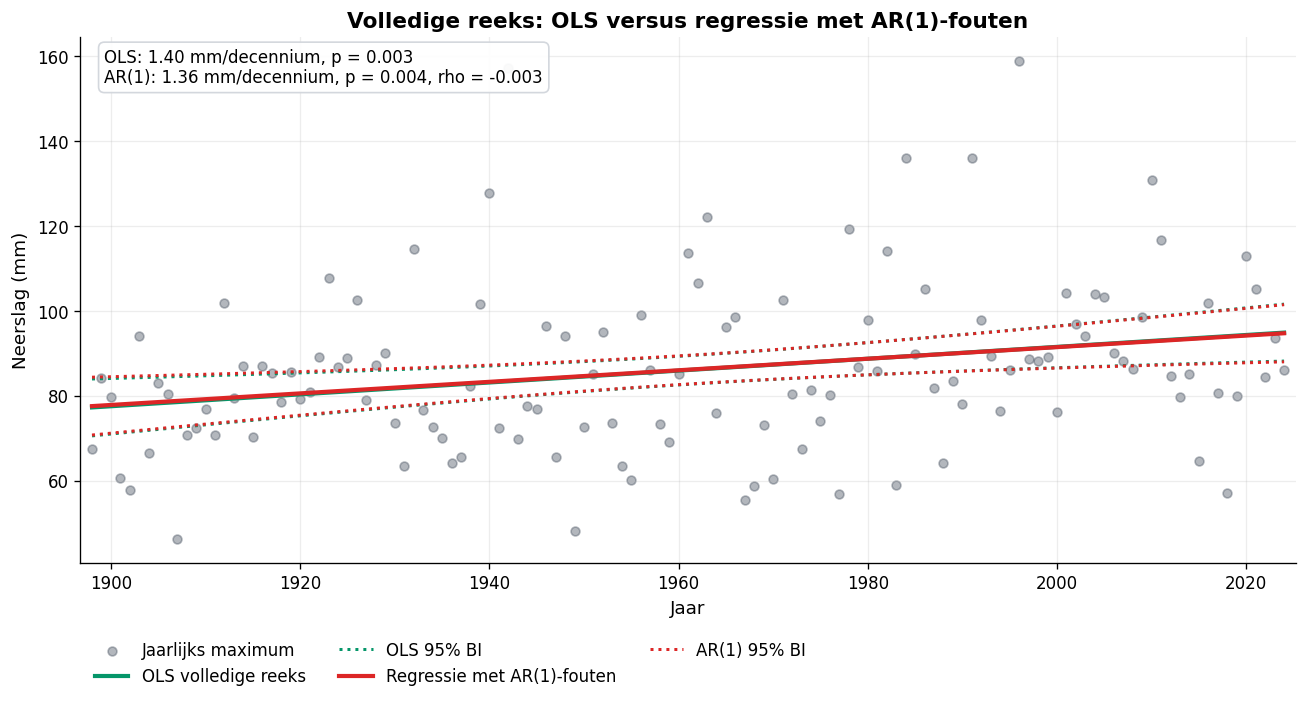

In [7]:
# Vergelijking: gewone OLS versus lineaire regressie met AR(1)-fouten
X_full = sm.add_constant(t_full)

ols_full_compare = sm.OLS(values, X_full).fit()
glsar_full = sm.GLSAR(values, X_full, rho=1)
ar1_full = glsar_full.iterative_fit(maxiter=20)
rho_ar1 = float(np.squeeze(glsar_full.rho))

ols_pred = ols_full_compare.get_prediction(X_full).summary_frame(alpha=0.05)
ar1_pred = ar1_full.get_prediction(X_full).summary_frame(alpha=0.05)

comparison_table = pd.DataFrame({
    'Model': ['OLS volledige reeks', 'Regressie met AR(1)-fouten'],
    'Intercept': [ols_full_compare.params[0], ar1_full.params[0]],
    'Trend (mm/decennium)': [ols_full_compare.params[1] * 10, ar1_full.params[1] * 10],
    'Std. fout trend': [ols_full_compare.bse[1] * 10, ar1_full.bse[1] * 10],
    'p-waarde trend': [format_p(ols_full_compare.pvalues[1]), format_p(ar1_full.pvalues[1])],
    'CI95 trend laag': [ols_full_compare.conf_int(alpha=0.05)[1, 0] * 10, ar1_full.conf_int(alpha=0.05)[1, 0] * 10],
    'CI95 trend hoog': [ols_full_compare.conf_int(alpha=0.05)[1, 1] * 10, ar1_full.conf_int(alpha=0.05)[1, 1] * 10],
    'AR(1) rho': [np.nan, rho_ar1],
    'R-kwadraat': [ols_full_compare.rsquared, ar1_full.rsquared],
})

ols_tests = pd.DataFrame({
    'Model': 'OLS volledige reeks',
    'Test': ['F-test p-waarde', 'Durbin-Watson', 'Ljung-Box lag 10 p-waarde'],
    'Waarde': [
        format_p(ols_full_compare.f_pvalue),
        durbin_watson(ols_full_compare.resid),
        format_p(acorr_ljungbox(ols_full_compare.resid, lags=[10], return_df=True).loc[10, 'lb_pvalue']),
    ],
})

ar1_tests = pd.DataFrame({
    'Model': 'Regressie met AR(1)-fouten',
    'Test': ['Geschatte AR(1) rho', 'Durbin-Watson', 'Ljung-Box lag 10 p-waarde'],
    'Waarde': [
        rho_ar1,
        durbin_watson(ar1_full.resid),
        format_p(acorr_ljungbox(ar1_full.resid, lags=[10], return_df=True).loc[10, 'lb_pvalue']),
    ],
})

display(comparison_table.round({
    'Intercept': 3,
    'Trend (mm/decennium)': 3,
    'Std. fout trend': 3,
    'CI95 trend laag': 3,
    'CI95 trend hoog': 3,
    'AR(1) rho': 4,
    'R-kwadraat': 4,
}))
display(pd.concat([ols_tests, ar1_tests], ignore_index=True))

fig, ax = plt.subplots()
ax.scatter(years, values, color=COLORS['observed'], alpha=0.42, s=28, label='Jaarlijks maximum')

ax.plot(years, ols_pred['mean'], color=COLORS['accent'], linewidth=2.5, label='OLS volledige reeks')
ax.plot(years, ols_pred['mean_ci_lower'], color=COLORS['accent'], linestyle=':', linewidth=1.8, label='OLS 95% BI')
ax.plot(years, ols_pred['mean_ci_upper'], color=COLORS['accent'], linestyle=':', linewidth=1.8)

ax.plot(years, ar1_pred['mean'], color=COLORS['recent'], linewidth=2.5, label='Regressie met AR(1)-fouten')
ax.plot(years, ar1_pred['mean_ci_lower'], color=COLORS['recent'], linestyle=':', linewidth=1.8, label='AR(1) 95% BI')
ax.plot(years, ar1_pred['mean_ci_upper'], color=COLORS['recent'], linestyle=':', linewidth=1.8)

ax.text(
    0.02,
    0.98,
    f'OLS: {ols_full_compare.params[1] * 10:.2f} mm/decennium, p = {ols_full_compare.pvalues[1]:.3f}\n'
    f'AR(1): {ar1_full.params[1] * 10:.2f} mm/decennium, p = {ar1_full.pvalues[1]:.3f}, rho = {rho_ar1:.3f}',
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox={'facecolor': 'white', 'edgecolor': '#D1D5DB', 'alpha': 0.94, 'boxstyle': 'round,pad=0.35'},
)
ax.set_title('Volledige reeks: OLS versus regressie met AR(1)-fouten')
ax.set_xlabel('Jaar')
ax.set_ylabel('Neerslag (mm)')
ax.legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=3)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()


Er zijn nauwelijks verschillen tussen beide methoden wat er op awijst dat de autocorrelatie mogelijk geen effect heeft op de betrouwbaarheidsiontervallen en de schatting van de standaardfout.

### 4.2.2. Vergelijking: gewone OLS versus OLS met HAC/Newey-West robuuste onzekerheid

HAC = heteroskedasticity and autocorrelation consistent. Newey-West corrigeert dus de standaardfouten voor:

-heteroskedasticiteit: ongelijke variantie van residuen;
-autocorrelatie: samenhang tussen residuen over naburige jaren.

In praktijk betekent dit vaak: dezelfde regressielijn, maar bredere betrouwbaarheidsintervallen en hogere p-waarden dan bij naïeve OLS, zeker als er positieve autocorrelatie zit in de residuen.

Bij tijdreeksen is de onzekerheid rond een geschatte trend niet alleen afhankelijk van de spreiding van de individuele residuen rond de regressielijn. Ook de samenhang tussen opeenvolgende residuen speelt een belangrijke rol. Wanneer residuen positief autocorreleren, betekent dit dat een positieve afwijking in het ene jaar vaak gevolgd wordt door een positieve afwijking in een volgend jaar, en omgekeerd. De observaties leveren dan minder onafhankelijke informatie dan wanneer elk jaar volledig los zou staan van de vorige jaren.

In klassieke OLS wordt de variantie van de schatter vooral gebaseerd op de variantie van de afzonderlijke residuen. Bij tijdreeksen is dat vaak te beperkt. De relevante variantie bevat niet alleen de gewone residuvariantie, maar ook de autocovarianties tussen residuen op verschillende tijdsafstanden. Schematisch kan men die zogenaamde langetermijnvariantie schrijven als:
$$γ0​+2γ1​+2γ2​+2γ3​+⋯$$

Daarbij staat γ0 voor de gewone variantie van de residuen. γ1 is de autocovariantie tussen residuen die één periode uit elkaar liggen, bijvoorbeeld tussen jaar t en jaar t−1. γ2 is de autocovariantie tussen residuen die twee jaren uit elkaar liggen, enzovoort... De termen worden met factor 2 opgenomen omdat de samenhang in beide richtingen meetelt: de covariantie tussen t en t−1 is dezelfde informatie als tussen t−1 en t.

De Newey-West-correctie probeert deze langetermijnvariantie te schatten. Ze doet dat niet door alle mogelijke autocovarianties onbeperkt mee te nemen, want dat zou bij een eindige tijdreeks te instabiel worden. In plaats daarvan wordt de som afgekapt na een gekozen aantal lags L. Alleen autocorrelatie tot en met die lag wordt dus meegenomen. Bovendien krijgen verder verwijderde lags een lager gewicht. Autocorrelatie tussen opeenvolgende jaren telt zwaarder mee dan autocorrelatie tussen jaren die verder uit elkaar liggen.

Daarom wordt HAC/Newey-West vaak beschreven als een schatter van de long-run variance. Dat is de variantie die relevant is wanneer observaties doorheen de tijd niet onafhankelijk zijn. In plaats van te doen alsof elk jaar een volledig nieuwe, onafhankelijke observatie is, houdt HAC rekening met het feit dat opeenvolgende jaren gedeeltelijk dezelfde onderliggende variatie kunnen delen.

Dit heeft directe gevolgen voor de standaardfout van de geschatte trendhelling. Stel dat de residuen positief autocorreleren:

$$
Cov(ut​,ut−1​)>0
$$

Dan bevatten bijvoorbeeld 120 jaarlijkse observaties minder onafhankelijke informatie dan 120 volledig onafhankelijke observaties. De effectieve steekproefgrootte is dan kleiner dan het nominale aantal jaren suggereert. Een gewone OLS-standaardfout houdt daar geen rekening mee en behandelt de 120 jaren alsof ze volledig onafhankelijk zijn. Daardoor wordt de onzekerheid rond de trendhelling vaak onderschat.

De HAC/Newey-West-correctie past dit aan. Ze laat de geschatte OLS-trend zelf ongemoeid, maar corrigeert de standaardfout van die trendhelling voor autocorrelatie en heteroskedasticiteit. Bij positieve autocorrelatie leidt dit vaak tot een grotere standaardfout, een breder betrouwbaarheidsinterval en een hogere p-waarde dan bij de klassieke OLS-berekening.

In formulevorm gaat het vaak van:
$$
SE(klassieke OLS​<SEHAC/Newey-West)​
$$

en dus meestal ook:
$$
p(klassieke OLS​<pHAC/Newey-West)​
$$

Dat is echter geen wiskundige garantie in elke toepassing. Het hangt af van de richting en sterkte van de autocorrelatie, de gekozen laglengte en de structuur van de residuen. Methodologisch is de hoofdboodschap dat HAC/Newey-West een robuustere onzekerheidsinschatting geeft dan naïeve OLS wanneer de data een tijdreeks vormen. De methode corrigeert dus de inferentie rond de trend, maar verandert niet het onderliggende model: het blijft een globale lineaire trend over de gekozen periode.

*Voor deze HAC/Newey-West-variantie die we gebruikten werd een maximale laglengte van 4 jaren gebruikt. Dit betekent dat autocovarianties tussen residuen tot en met vier jaar afstand worden meegenomen, met dalende Bartlett-gewichten. Deze keuze sluit aan bij gangbare vuistregels voor jaarlijkse tijdreeksen van ongeveer 120 observaties.*

,Model,Intercept,Trend (mm/decennium),Std. fout trend,t-waarde trend,p-waarde trend,CI95 trend laag,CI95 trend hoog,HAC maxlags
0,OLS standaard,77.297,1.399,0.465,3.011,"0,003",0.479,2.318,NaN
1,OLS HAC/Newey-West,77.297,1.399,0.398,3.511,"<0,001",0.610,2.187,4.0


,Kenmerk,Waarde
0,Aantal jaren,127
1,Periode,1898-2024
2,R-kwadraat,0.067606
3,Durbin-Watson residualen,2.002129
4,Ljung-Box lag 10 p-waarde,"0,544"
5,HAC/Newey-West maxlags,4


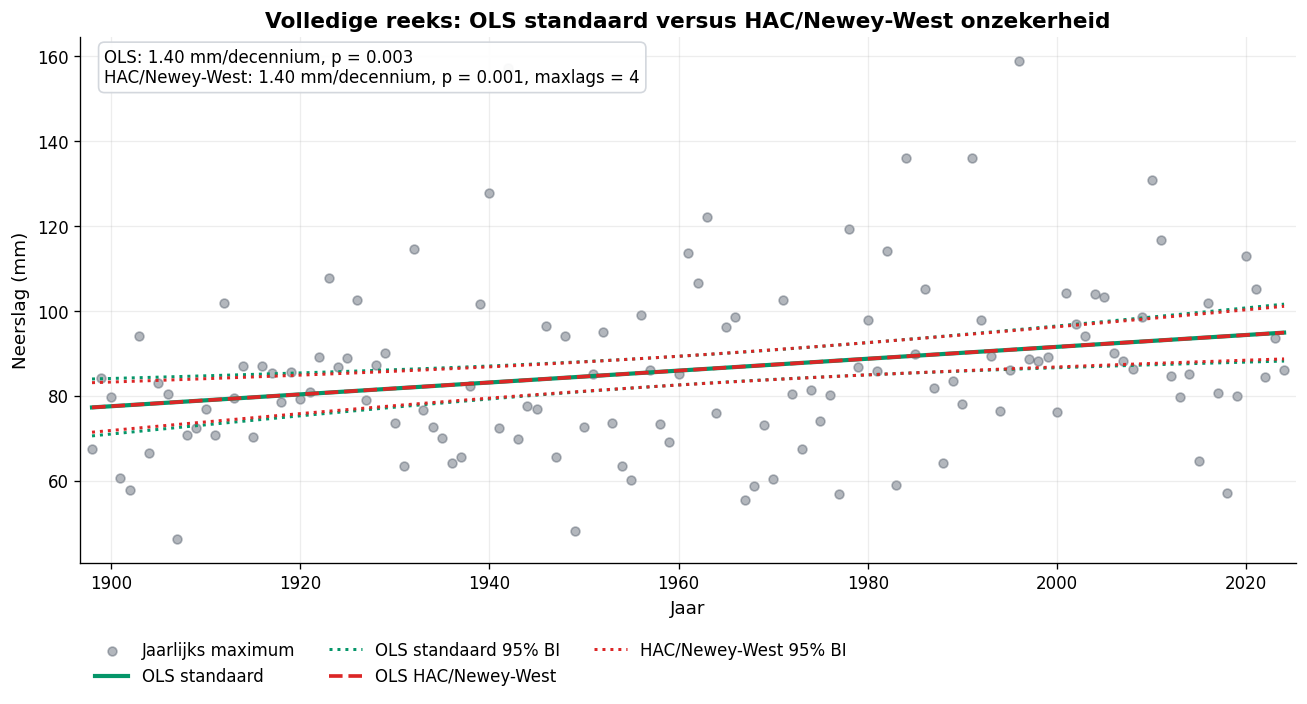

In [8]:
# Vergelijking: gewone OLS versus OLS met HAC/Newey-West robuuste onzekerheid
X_full = sm.add_constant(t_full)

ols_classic = sm.OLS(values, X_full).fit()
nw_lags_full = hac_lags(len(extreme))
ols_hac = ols_classic.get_robustcov_results(cov_type='HAC', maxlags=nw_lags_full)

ols_classic_pred = ols_classic.get_prediction(X_full).summary_frame(alpha=0.05)

hac_mean = X_full @ ols_hac.params
hac_cov = ols_hac.cov_params()
hac_mean_se = np.sqrt(np.sum((X_full @ hac_cov) * X_full, axis=1))
hac_tcrit = stats.t.ppf(0.975, df=ols_hac.df_resid)
hac_ci_low = hac_mean - hac_tcrit * hac_mean_se
hac_ci_high = hac_mean + hac_tcrit * hac_mean_se

ols_hac_table = pd.DataFrame({
    'Model': ['OLS standaard', 'OLS HAC/Newey-West'],
    'Intercept': [ols_classic.params[0], ols_hac.params[0]],
    'Trend (mm/decennium)': [ols_classic.params[1] * 10, ols_hac.params[1] * 10],
    'Std. fout trend': [ols_classic.bse[1] * 10, ols_hac.bse[1] * 10],
    't-waarde trend': [ols_classic.tvalues[1], ols_hac.tvalues[1]],
    'p-waarde trend': [format_p(ols_classic.pvalues[1]), format_p(ols_hac.pvalues[1])],
    'CI95 trend laag': [ols_classic.conf_int(alpha=0.05)[1, 0] * 10, ols_hac.conf_int(alpha=0.05)[1, 0] * 10],
    'CI95 trend hoog': [ols_classic.conf_int(alpha=0.05)[1, 1] * 10, ols_hac.conf_int(alpha=0.05)[1, 1] * 10],
    'HAC maxlags': [np.nan, nw_lags_full],
})

ols_hac_tests = pd.DataFrame({
    'Kenmerk': [
        'Aantal jaren',
        'Periode',
        'R-kwadraat',
        'Durbin-Watson residualen',
        'Ljung-Box lag 10 p-waarde',
        'HAC/Newey-West maxlags',
    ],
    'Waarde': [
        int(ols_classic.nobs),
        f'{int(years.min())}-{int(years.max())}',
        ols_classic.rsquared,
        durbin_watson(ols_classic.resid),
        format_p(acorr_ljungbox(ols_classic.resid, lags=[10], return_df=True).loc[10, 'lb_pvalue']),
        nw_lags_full,
    ],
})

display(ols_hac_table.round({
    'Intercept': 3,
    'Trend (mm/decennium)': 3,
    'Std. fout trend': 3,
    't-waarde trend': 3,
    'CI95 trend laag': 3,
    'CI95 trend hoog': 3,
    'HAC maxlags': 0,
}))
display(ols_hac_tests)

fig, ax = plt.subplots()
ax.scatter(years, values, color=COLORS['observed'], alpha=0.42, s=28, label='Jaarlijks maximum')

ax.plot(years, ols_classic_pred['mean'], color=COLORS['accent'], linewidth=2.5, label='OLS standaard')
ax.plot(years, ols_classic_pred['mean_ci_lower'], color=COLORS['accent'], linestyle=':', linewidth=1.8, label='OLS standaard 95% BI')
ax.plot(years, ols_classic_pred['mean_ci_upper'], color=COLORS['accent'], linestyle=':', linewidth=1.8)

ax.plot(years, hac_mean, color=COLORS['recent'], linewidth=2.2, linestyle='--', label='OLS HAC/Newey-West')
ax.plot(years, hac_ci_low, color=COLORS['recent'], linestyle=':', linewidth=1.8, label='HAC/Newey-West 95% BI')
ax.plot(years, hac_ci_high, color=COLORS['recent'], linestyle=':', linewidth=1.8)

ax.text(
    0.02,
    0.98,
    f'OLS: {ols_classic.params[1] * 10:.2f} mm/decennium, p = {ols_classic.pvalues[1]:.3f}\n'
    f'HAC/Newey-West: {ols_hac.params[1] * 10:.2f} mm/decennium, p = {ols_hac.pvalues[1]:.3f}, maxlags = {nw_lags_full}',
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox={'facecolor': 'white', 'edgecolor': '#D1D5DB', 'alpha': 0.94, 'boxstyle': 'round,pad=0.35'},
)
ax.set_title('Volledige reeks: OLS standaard versus HAC/Newey-West onzekerheid')
ax.set_xlabel('Jaar')
ax.set_ylabel('Neerslag (mm)')
ax.legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=3)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()


Ook deze methodiek die op een meer robustere manier dan enkel een AR(1) schatting corrigeerd op de effecten van autocorrelatie zonder de punt schatting van de helling te beïnvloeden geeft geen verschillen met betrekking tot de vergelijking met een enkelvoudige regressie.

Daarbij dient men wel bij de interpretatie op te letten: 

**HAC of AR lost het hoofdprobleem van een globale lineaire trend over 120 jaar niet op. Ze corrigeren vooral de onzekerheid rond de regressiehelling bij autocorrelatie (en heteroscedasticiteit). Maar ze beantwoorden niet de vraag of één rechte lijn over de volledige klimaatperiode inhoudelijk een geschikt trendmodel is.**

## 4.2.3. Diagnostiek van de regressie vanaf 1981

We deden ook de test voor de de recente trend die we hierboven reeds uitvoerden. Deze is immers ook enkel betrouwbaar qua interferentie (sign test)  wanneer de residuen niet sterk gestructureerd/autocorrelatie vertonen. Daarom controleren we autocorrelatie expliciet met lag-1 autocorrelatie, Durbin-Watson en Ljung-Box tests.


,Diagnose,Waarde
0,Aantal jaren sinds 1981,44.0000
1,HAC maxlags,3.0000
2,Lag-1 autocorrelatie residualen,-0.0722
3,Durbin-Watson residualen,2.1360


,Ljung-Box statistic,p-waarde
1,0.2431,0.6220
5,7.8714,0.1635
10,12.9023,0.2292


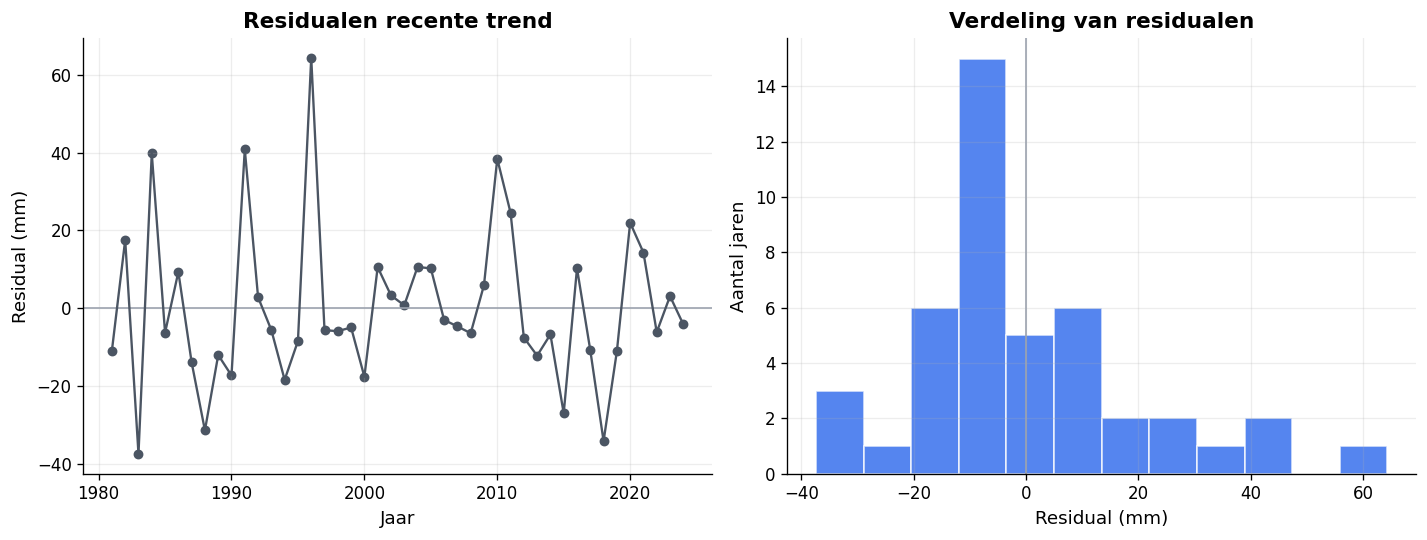

In [9]:
residuals_recent = pd.Series(ols_recent.resid, index=recent['Jaar'])
residual_diagnostics = pd.DataFrame({
    'Diagnose': [
        'Aantal jaren sinds 1981',
        'HAC maxlags',
        'Lag-1 autocorrelatie residualen',
        'Durbin-Watson residualen',
    ],
    'Waarde': [
        len(recent),
        recent_hac_lags,
        residuals_recent.autocorr(lag=1),
        durbin_watson(residuals_recent),
    ],
})

ljung_box = (
    acorr_ljungbox(residuals_recent, lags=[1, 5, 10], return_df=True)
    .rename(columns={'lb_stat': 'Ljung-Box statistic', 'lb_pvalue': 'p-waarde'})
)

display(residual_diagnostics.round(4))
display(ljung_box.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].axhline(0, color=COLORS['neutral'], linewidth=1)
axes[0].plot(residuals_recent.index, residuals_recent, color=COLORS['observed'], linewidth=1.4)
axes[0].scatter(residuals_recent.index, residuals_recent, color=COLORS['observed'], s=24)
axes[0].set_title('Residualen recente trend')
axes[0].set_xlabel('Jaar')
axes[0].set_ylabel('Residual (mm)')

axes[1].hist(residuals_recent, bins=12, color=COLORS['loess'], alpha=0.78, edgecolor='white')
axes[1].axvline(0, color=COLORS['neutral'], linewidth=1)
axes[1].set_title('Verdeling van residualen')
axes[1].set_xlabel('Residual (mm)')
axes[1].set_ylabel('Aantal jaren')
plt.tight_layout()
plt.show()


**Interpretatie diagnostiek**

De diagnostiek geeft geen aanwijzing voor problematische autocorrelatie in de residualen van de recente regressie. De lag-1 autocorrelatie is klein en licht negatief (`-0,072`), terwijl een Durbin-Watsonwaarde van `2,14` dicht bij de referentiewaarde `2` ligt. Dat past bij residualen die niet systematisch jaar-op-jaar blijven doorwerken.

Ook de Ljung-Box tests blijven ruim boven de gebruikelijke 5%-grens (`p = 0,62` bij lag 1, `p = 0,16` bij lag 5 en `p = 0,23` bij lag 10). We verwerpen dus niet de nulhypothese dat de residualen geen autocorrelatie bevatten. De figuur ondersteunt dat beeld: de residualen schommelen rond nul zonder duidelijke opeenvolgende blokken of trend, al blijft de spreiding visueel niet perfect normaal.

Voor de trendinterpretatie betekent dit dat de lineaire regressie vanaf 1981 niet duidelijk wordt ondermijnd door autocorrelatie in de fouttermen. Het gebruik van HAC/Newey-West standaardfouten met `maxlags = 3` blijft wel zinvol als voorzichtige rapportagekeuze, omdat de steekproef beperkt is en jaarlijkse klimaatreeksen methodisch gevoelig kunnen zijn voor temporele afhankelijkheid.

Belangrijk: deze diagnostiek bewijst niet dat de oorspronkelijke neerslagreeks stationair is. Ze zegt alleen dat de residualen van dit recente lineaire model geen duidelijke autocorrelatiestructuur tonen. Voor stationariteit van de oorspronkelijke reeks zou een aparte tijdreeksanalyse nodig zijn.


# Conclusie

VMM gebruikt met OLS een statistisch herkenbare techniek, maar op de volledige reeks is die is niet dezelfde als de klimatologische analysemethodiek die KMI/KNMI als hoofdbenadering gebruiken voor lange klimaatreeksen.

In de klimatologische literatuur (o.a. KNMI TR-389) wordt afgeraden om lange klimaattijdreeksen uitsluitend met een globale lineaire trend te beschrijven. Dergelijke reeksen kunnen niet-lineaire evoluties en regimewissels vertonen. Daarom wordt aanbevolen om smoothing-technieken zoals LOESS te gebruiken voor de volledige periode en lineaire trends vooral te berekenen voor recente deelperiodes. 

De globale OLS-trend blijft in deze mogelijk nuttig als replicatie en vergelijking met de VMM-communicatie. Alhoewel één van de belangrijkste methodologische redenen om geen OLS regressie toe te passen op tijdreeksen, van uit de basis GAUSS-Markov voorwaarden voor OLS, de aanwezigheid van autocorrelatie is. Bleek dit na toetsing niet het geval. Dit neemt echter niet weg dat het toepassen hiervan voor het berekenen of communiceren een klimaattrends aangewezen is als good-practise . We konden dit vrij goed illuistreren op basis van gevoeligheidsanalyse van het startpunt van de regressie analyse.  

De hoofdinterpretatie moet  steunen op de combinatie van LOESS voor de vorm van de langetermijnevolutie te viosualiseren, en de recente trend van de laatste 30 jaar met expliciete onzekerheid, als diagnostiek van de recente trend. 

Verder vermeld de literatuur van klimatologisch onderzoek dat voor neerslagextremen terughoudendheid extra belangrijk is voor trendanalyses door de grote natuurlijke variabiliteit. Dit laatste toonden we wel degelijk aan op basis van een gevoeligheidsanalyse voor het startpunt mbt een regressierechte. 

we herhalen tot slot onze conclusie op basis van de literatuur:

> De methodologische kernconclusie is dus niet dat lineaire regressie als techniek 'fout' is. De kern is dat één globale lineaire regressie over een lange klimaatreeks een te sterke en te weinig klimatologische modelkeuze is om als centrale trendboodschap te gebruiken. Een wetenschappelijk robuustere aanpak combineert een gladde lokale trendlijn voor de volledige reeks met een aparte, expliciet afgebakende analyse van recente verandering. Dat sluit beter aan bij de methodologische redenering van KNMI TR-389 en bij de manier waarop klimaatindicatoren voorzichtig moeten worden gecommuniceerd.





